📅 **论文年份 (Year):2024 年**
*Chameleon: Mixed-Modal Early-Fusion Foundation Models — Chameleon Team, Meta FAIR*

# Bonus Paper 36: Chameleon(混合模态早融合基础模型)
## Chameleon Team, Meta FAIR(Meta 基础 AI 研究团队)

### Implementation: One Autoregressive Transformer that Both Reads and Draws(实现:一个既能看图又能画图的自回归 Transformer)

This notebook implements the core idea of Chameleon in pure NumPy: **turn images into discrete tokens, mix them with text tokens in a single vocabulary, and train one causal Transformer with one next-token loss to do both understanding (image→caption) and generation (caption→image)**. No separate vision encoder, no bridge, no frozen towers — the two modalities are born mixed. We also situate Chameleon on the early-fusion / late-fusion spectrum (31 CLIP → 33 BLIP-2 → 34 LLaVA → 36 Chameleon) and connect it to the Show-o / Janus unified line and the 2026 "natively multimodal" trend.

本笔记本只用 NumPy 实现 Chameleon 的核心思想:**把图像变成离散 token,和文本 token 混进同一个词表,用一个因果 Transformer、一份 next-token 交叉熵损失,同时学会"看图答文"(理解)和"按文生图"(生成)**。没有独立的视觉编码器、没有桥接模块、没有冻结塔——两个模态生而混训。我们还会把 Chameleon 放到"早融合 vs 晚融合"的谱系里(31 CLIP → 33 BLIP-2 → 34 LLaVA → 36 Chameleon),并联系 Show-o / Janus 这条统一路线和 2026 年"原生多模态"趋势。

> 注:Chameleon 不在 Sutskever 原始 30 篇书单中,是本仓库多模态线的扩展 Bonus。它代表了与 33/34"桥接范式"针锋相对的另一条路:不是把预训练视觉塔接到语言模型上,而是从一开始就把图像 token 化、和文本一起自回归。

## 📖 论文导读

**🎯 这篇文章想解决什么问题(目的):** 当时主流的多模态大模型(BLIP-2、Flamingo、LLaVA,即本仓库 33/34)都是"桥接范式":拿一个预训练好的视觉编码器(CLIP/ViT)+ 一个预训练好的语言模型,中间接一座桥(Q-Former 或一层投影)把图像特征"翻译"进语言模型的词嵌入空间。这条路能看图说话,却很难反过来**生成图像**——因为视觉端是连续特征、语言端是离散 token,两者是"缝合"起来的,不是同一种货币。Chameleon 想回答:能不能干脆让图像也变成离散 token,和文本 token 使用**同一个词表、同一个 Transformer、同一个损失**,让理解和生成成为同一个模型的两个方向?

**💡 主要贡献:** Chameleon 提出**早融合(early-fusion)**的 token-in-token-out 架构:(1) 用一个 VQ 图像分词器把任意图像编码成离散 code 序列,和文本 subword 拼进一个统一词表;(2) 用一个标准自回归 Transformer,在图文任意交错的序列上做 next-token 预测——**一份权重**既能续写文本、也能续写图像;(3) 为了让图像 token 和文本 token 混训时不发散,采用 QK-Norm(Henry et al. 2020 提出,对注意力的 query/key 做归一化)等稳定性技巧;(4) 证明了单一模型在图文理解和图文生成两个方向上都能达到有竞争力的水平。

**🔧 方法:** 图像 → VQ 分词器 → 一串离散 code;文本 → 一串 subword token;两者共享一个词表(文本词 + 图像 code + `[BOI]`/`[EOI]` 等特殊符)。训练样本是图文交错序列,例如 `caption [BOI] 图像tokens [EOI]`(文生图方向)或 `[BOI] 图像tokens [EOI] caption`(图生文方向),全部塞进同一个 batch,用同一个因果 Transformer、同一个交叉熵损失训练。推理时想生成图像就在 `[BOI]` 后自回归采样 code、再经 VQ 解码回像素;想理解图像就把图像 token 当前缀、让模型续写文字。本笔记本用 16×16 彩色几何图形(3 色 × 3 形)复现整条流水线:玩具 VQ 分词器(k-means 学 96 码的码本)、统一词表、手写反向传播的因果 Transformer、双向混合训练,以及与"单向训练"的招牌消融。

**🌟 意义:** Chameleon 把"多模态"从"缝合两个专家"推进到"一个通才生而混训"。它统一了理解与生成、放弃了模态间的桥,代价是图像必须离散化——而 VQ 的重建损失就成了生成画质的天花板(这正是真实 Chameleon 图像质量受限、后续 Transfusion 改用连续扩散头的原因)。这条"统一 token 流"的路线随后被 Show-o、Janus 等继承,并汇入 2026 年"原生多模态基础模型"的主流叙事:一个模型,一套 token,读写通吃。

## 🎯 核心结论 (Key Takeaways)

- **一份权重,两种能力,靠混训买来。** 一个 10.6 万参数、纯 NumPy 手写反传的因果 Transformer,在图文交错序列上混合训练后,**理解方向**(看图生成 caption)达到 **86.0% 精确匹配准确率**,**生成方向**(按 prompt 生成图像 token→解码→独立评委判类)达到 **77.3%**——同一个模型、同一个 next-token 损失,没有任何桥接或冻结塔。

- **自回归生成图像必须先离散化。** 自回归的每一步是在词表上做 softmax,softmax 需要**有限个类别**;连续的像素/特征无法直接被 argmax/采样。所以 Chameleon 先用 VQ 把图像压成 96 个离散 code 之一的序列——图像从此和文本一样,是"从有限词表里选下一个 token"。

- **VQ 的重建损失就是生成画质的天花板。** 码本大小 K 从 8→64,测试集重建 MSE 从 0.0190 降到 **0.0080**(本文实际采用 K=96);独立评委分类器在 VQ 重建图上的准确率为 **89.0%**——这个数字就是生成方向准确率的硬上限。**离散化省了自回归的麻烦,却给画质设了天花板**,这正是真实 Chameleon 后来被 Transfusion(连续扩散头)超越的原因。

- **招牌消融:单向训练只给你一半能力。** 把同一个模型**只用文生图数据**训练,它的生成方向照样不错(81.3%),但理解方向(看图说话)准确率塌到 **0.0%**——完全不会。**"一份权重两种能力"不是架构免费送的,是双向混训一个 token 一个 token 喂出来的。**

- **早融合没有桥,所有参数共享。** 对比 33(冻结双塔 + Q-Former 桥)、34(冻结塔 + 投影层),本篇 **10.6 万参数全部参与训练、全部共享**:图像 code 和文本词用同一张嵌入表、走同一叠注意力层。参数表里没有"冻结塔"这一栏。

- **梯度不会说谎。** 穿过因果 softmax 注意力、残差、RMSNorm 的手写反向传播,与数值梯度的相对误差最大仅 **3.4e-8**(< 1e-4)。

## 🤯 反常识的发现 (Counterintuitive Findings)

- **常识认为:理解和生成是两类模型(判别 vs 生成),得分开做。** Chameleon 证明它们只是同一个自回归模型的**两个方向**:把图像 token 放前面让模型续写文字 = 理解;把文字放前面让模型续写图像 token = 生成。本实验里同一份权重同时做到 86.0%(理解)和 77.3%(生成)。

- **常识认为:图像是连续的,硬压成几十个离散 code 肯定丢很多信息、没法用。** 恰恰相反:离散化是自回归生成图像的**前提**(softmax 需要有限词表),而且 96 个 code 的码本已经能让独立分类器在重建图上达到 89.0% 准确率。代价是真实存在的——重建 MSE 就是画质天花板——但"够用"到能训练出一个会画画的语言模型。

- **常识认为:模型只要见过"红色"和"三角形",混训后自然什么方向都会。** 本实验的消融给出反例:只喂文生图数据的模型,生成方向 81.3%,理解方向却只有 0.0%——它从没被要求"看图输出文字",于是这个方向的能力根本不存在。**能力是被损失函数在特定方向上"要求"出来的,不是权重里自动长出来的。**

- **常识认为:把图像 token 和文本 token 混进一个词表,训练会因为两种 token 统计差异巨大而发散。** 这确实是早融合的真实难点(Chameleon 论文专门提出 QK-Norm、调整 norm 位置来稳住训练)。本玩具实现里我们用了一个更朴素但同样有效的处理:**按方向平衡损失权重**——让"生成方向的 17 个图像 token 损失"和"理解方向的 3 个文字 token 损失"对每个样本贡献相等的梯度,否则数量占优的图像 token 会淹没文字信号,理解能力会在训练后期悄悄退化。

#### 💻 代码解读

**做什么:** 导入依赖并固定随机种子,保证实验可复现。

**怎么做:**
- 只用 `numpy`(数值计算)和 `matplotlib`(画图),与本仓库其他 notebook 一致——不依赖任何深度学习框架,VQ、Transformer、反向传播全部手写。
- 固定两个随机源:全局 `np.random.seed` 和新式 `default_rng`;数据生成、码本初始化、参数初始化、采样都走 `rng`,结果完全可复现。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
# 新式随机数生成器:数据生成、k-means、参数初始化、采样都用它,保证可复现
rng = np.random.default_rng(0)

## 合成数据集:彩色几何图形(图像 + 文字标题)

#### 💻 代码解读

**做什么:** 生成 16×16×3 的彩色几何图形:3 种颜色 × 3 种形状 = 9 个类别,带位置/大小抖动和噪声(与本仓库 31/32 同款生成器,方便横向对比)。每张图天然对应一句标题 "a {color} {shape}"。

**怎么做:**
- `draw_image`:用 `np.mgrid` 一次生成全部像素坐标,再用布尔掩码向量化"画图"——圆是距离方程、方形是切比雪夫距离、三角形是三个半平面的交集,全程无循环。
- 位置抖动(圆心 5.5~10.5)和大小抖动(半径 3~5)迫使模型学"概念"而非死记像素,也让每类图像产生**多样的 VQ token 序列**——这正是自回归生成有意义的前提。
- `make_dataset` 均匀采样 9 类;标签 0~8 同时决定图像和标题。

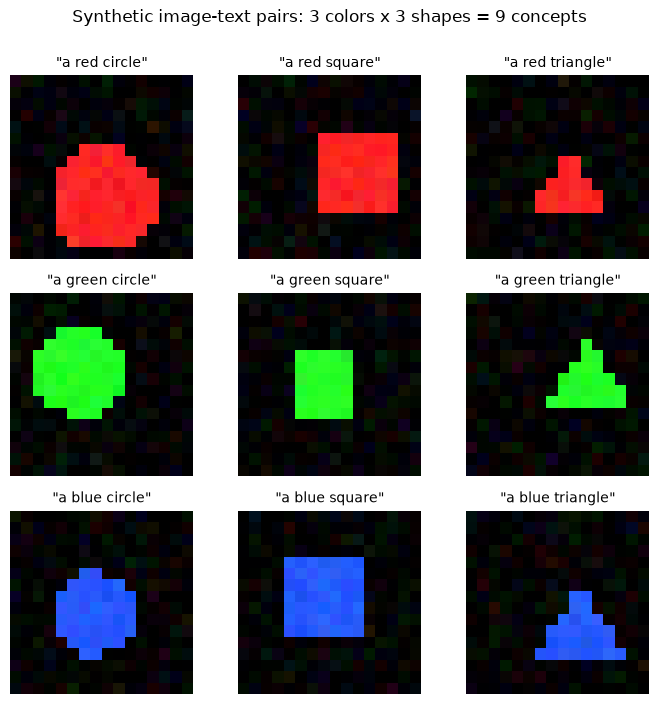

Train: (2400, 16, 16, 3), Test: (300, 16, 16, 3)


In [2]:
# 3种颜色 x 3种形状 = 9个类别
COLORS = {'red': (1.0, 0.15, 0.15), 'green': (0.15, 1.0, 0.15), 'blue': (0.15, 0.35, 1.0)}
SHAPES = ['circle', 'square', 'triangle']
ALL_PAIRS = [(c, s) for c in COLORS for s in SHAPES]
IMG = 16  # 图像尺寸 16x16x3

def draw_image(color, shape, rng):
    """Draw one colored shape with position/size jitter and noise"""
    img = np.zeros((IMG, IMG, 3))
    img += rng.normal(0, 0.04, img.shape)  # 背景噪声
    # 位置和大小随机抖动:迫使模型学"概念",也让同类图产生多样的token序列
    cx, cy = rng.uniform(5.5, 10.5, 2)
    r = rng.uniform(3.0, 5.0)
    # np.mgrid一次生成所有像素的(行,列)坐标网格,形状均为(16,16)
    yy, xx = np.mgrid[0:IMG, 0:IMG]
    if shape == 'circle':
        # 布尔掩码:到圆心距离平方<=r^2的像素为True,向量化代替双重循环
        mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= r ** 2
    elif shape == 'square':
        mask = (np.abs(xx - cx) <= r * 0.8) & (np.abs(yy - cy) <= r * 0.8)
    else:  # triangle
        # 三角形=三条边的半平面交集:顶点在上,宽度随y线性增大
        mask = ((yy - (cy - r) >= 0) & (yy - (cy - r) <= 1.5 * r)
                & (np.abs(xx - cx) <= (yy - (cy - r)) / 1.5))
    img[mask] = COLORS[color]  # 花式索引:mask为True的像素一次性赋色
    img += rng.normal(0, 0.03, img.shape)
    return np.clip(img, 0, 1)

def make_dataset(n, rng):
    """Generate n labeled images; label picks both the pixels and the caption"""
    X, y = [], []
    for _ in range(n):
        k = rng.integers(9)
        c, s = ALL_PAIRS[k]
        X.append(draw_image(c, s, rng))
        y.append(k)
    return np.array(X), np.array(y)

Xtr, ytr = make_dataset(2400, rng)
Xte, yte = make_dataset(300, rng)

# 可视化9个类别各一个样本,标题即其配对文本
fig, axes = plt.subplots(3, 3, figsize=(7, 7))
for ax, (c, s) in zip(axes.flat, ALL_PAIRS):
    ax.imshow(draw_image(c, s, rng))
    ax.set_title(f'"a {c} {s}"', fontsize=10)
    ax.axis('off')
plt.suptitle('Synthetic image-text pairs: 3 colors x 3 shapes = 9 concepts', y=1.0)
plt.tight_layout()
plt.show()
print(f'Train: {Xtr.shape}, Test: {Xte.shape}')

## 图像离散化:玩具 VQ 分词器(为什么自回归生成图像必须先离散化)

#### 💻 代码解读

**做什么:** 构建一个玩具版 VQ(Vector-Quantized)图像分词器:把图像切成 16 个 4×4 patch,用 k-means 在 patch 上学一个 96 码的码本,于是"图像 ↔ 16 个离散 code 的序列"可逆转换。

**怎么做:**
- `patchify`/`unpatchify`:一次 reshape+transpose 把 (N,16,16,3) 切成 (N,16,48) 的 patch 序列,再逆回来(`assert` 确认可逆)。
- `kmeans`:标准 Lloyd 迭代,在 patch 向量(48 维)上聚成 K 类,每个聚类中心就是一个"视觉词"(码本条目)。
- `vq_encode`:每个 patch 找最近的码本条目,输出 16 个 code 下标(这就是图像的 token 化);`vq_decode`:把 code 换回码本 patch 再拼回图像(还原)。距离用 `||p||²-2p·C+||C||²` 的向量化展开,避免显式循环。
- **为什么必须离散化?** 自回归模型每一步在词表上做 softmax、再 argmax 或采样——这要求候选是**有限个离散类别**。连续的像素值无法被 softmax/采样。VQ 把"预测下一个像素块"变成"从 96 个视觉词里选一个",图像这才能像文本一样被自回归生成。
- 我们扫一遍 K∈{8,16,32,64} 看重建 MSE:**这条曲线就是生成画质的天花板**——码本越大画质越好,但图像词表也越大、生成越难学。

In [3]:
P = 4                   # patch 大小 4x4
NP_SIDE = IMG // P      # 每边4个patch
N_PATCH = NP_SIDE ** 2  # 共16个patch
D_PATCH = P * P * 3     # 每个patch展平后48维

def patchify(x):
    """(N,16,16,3) -> (N,16,48): 一次reshape+transpose切成4x4 patch"""
    N = x.shape[0]
    p = x.reshape(N, NP_SIDE, P, NP_SIDE, P, 3).transpose(0, 1, 3, 2, 4, 5)
    return p.reshape(N, N_PATCH, D_PATCH)

def unpatchify(pt):
    """(N,16,48) -> (N,16,16,3): patchify的逆操作"""
    N = pt.shape[0]
    p = pt.reshape(N, NP_SIDE, NP_SIDE, P, P, 3).transpose(0, 1, 3, 2, 4, 5)
    return p.reshape(N, IMG, IMG, 3)

assert np.allclose(unpatchify(patchify(Xte[:4])), Xte[:4])  # 确认可逆

def kmeans(X, K, rng, iters=20):
    """Lloyd's algorithm: learn K cluster centers = the visual codebook"""
    C = X[rng.choice(len(X), K, replace=False)].copy()  # 随机挑K个patch作初始中心
    for _ in range(iters):
        # 到每个中心的平方距离,展开成 ||x||^2 - 2 x.C + ||C||^2 (向量化)
        d = (X ** 2).sum(1)[:, None] - 2 * X @ C.T + (C ** 2).sum(1)[None]
        a = d.argmin(1)                        # 每个patch归到最近中心
        for k in range(K):
            sel = a == k
            if sel.any():
                C[k] = X[sel].mean(0)          # 中心更新为簇内均值
    return C

def vq_encode(imgs, C):
    """Image -> (N,16) code indices: each patch snaps to its nearest codebook entry"""
    pt = patchify(imgs).reshape(-1, D_PATCH)
    d = (pt ** 2).sum(1)[:, None] - 2 * pt @ C.T + (C ** 2).sum(1)[None]
    return d.argmin(1).reshape(len(imgs), N_PATCH)

def vq_decode(toks, C):
    """(N,16) code indices -> image: look up codebook patches and stitch back"""
    return unpatchify(C[toks].reshape(len(toks), N_PATCH, D_PATCH))

# 在训练集patch上学码本(抽12000个patch做k-means,加速)
patches_all = patchify(Xtr).reshape(-1, D_PATCH)
sub = patches_all[rng.choice(len(patches_all), 12000, replace=False)]

# 扫描码本大小K:重建MSE = 生成画质的天花板
print('codebook size K vs test-set reconstruction MSE (= the generation quality ceiling):')
K_sweep, mse_sweep = [8, 16, 32, 64], []
for Kt in K_sweep:
    Ct = kmeans(sub, Kt, np.random.default_rng(5))
    mse = ((vq_decode(vq_encode(Xte, Ct), Ct) - Xte) ** 2).mean()
    mse_sweep.append(mse)
    print(f'  K={Kt:3d}: recon MSE={mse:.5f}')

K = 96  # 选用96码:画质与图像词表大小的折中(码本越大画质越好,但生成越难学)
codebook = kmeans(sub, K, np.random.default_rng(5))
print(f'\nUsing K={K} codebook; each image = {N_PATCH} discrete tokens from a {K}-word visual vocabulary')

codebook size K vs test-set reconstruction MSE (= the generation quality ceiling):
  K=  8: recon MSE=0.01900
  K= 16: recon MSE=0.01390
  K= 32: recon MSE=0.01009


  K= 64: recon MSE=0.00802

Using K=96 codebook; each image = 16 discrete tokens from a 96-word visual vocabulary


#### 💻 代码解读

**做什么:** 可视化 VQ 分词器的两件事:(1) 码本长什么样——96 个 code 各自对应的 4×4 patch;(2) 一张图的"token 化 → 还原"全过程;外加重建 MSE vs 码本大小 K 的曲线。

**怎么做:**
- 左上:把码本 96 个条目各 reshape 成 4×4×3 的小 patch 平铺出来——这就是模型的"视觉词典"(可以看到不同颜色、不同边缘朝向的基元)。
- 右上:原图 → 16 个 code(标在网格上)→ 用码本还原的图,直观看到离散化的信息损失。
- 下方:MSE-vs-K 曲线,标注"这条线就是生成方向准确率的天花板"。

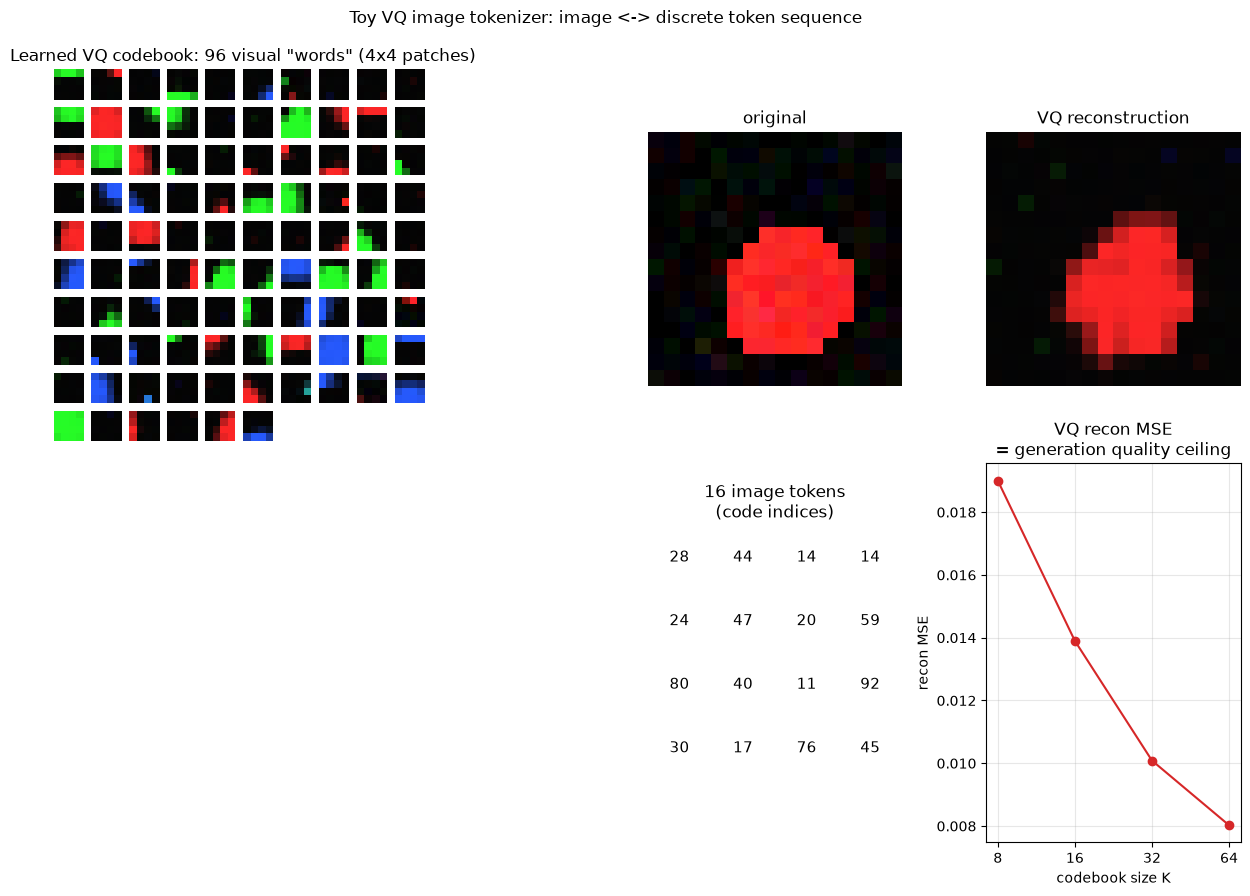

In [4]:
fig = plt.figure(figsize=(13, 9))

# (1) 码本可视化:K个视觉词各自的4x4 patch
ax1 = fig.add_subplot(2, 2, 1)
grid_side = int(np.ceil(np.sqrt(K)))          # 网格边长,容纳全部K个code
n_rows = int(np.ceil(K / grid_side))
canvas = np.ones((n_rows * (P + 1), grid_side * (P + 1), 3))
for i in range(K):
    r, c = divmod(i, grid_side)
    patch = np.clip(codebook[i].reshape(P, P, 3), 0, 1)
    canvas[r*(P+1):r*(P+1)+P, c*(P+1):c*(P+1)+P] = patch
ax1.imshow(canvas)
ax1.set_title(f'Learned VQ codebook: {K} visual "words" (4x4 patches)')
ax1.axis('off')

# (2) 一张图的 token 化 -> 还原
ax2 = fig.add_subplot(2, 4, 3)
demo = Xte[np.where(yte == 0)[0][0]]
codes = vq_encode(demo[None], codebook)[0]
recon = vq_decode(codes[None], codebook)[0]
ax2.imshow(demo); ax2.set_title('original'); ax2.axis('off')
ax3 = fig.add_subplot(2, 4, 4)
ax3.imshow(recon); ax3.set_title('VQ reconstruction'); ax3.axis('off')
# 把16个code的下标标在4x4网格上
ax4 = fig.add_subplot(2, 4, 7)
ax4.imshow(np.ones((NP_SIDE, NP_SIDE)), cmap='gray', vmin=0, vmax=1)
for k in range(N_PATCH):
    r, c = divmod(k, NP_SIDE)
    ax4.text(c, r, str(codes[k]), ha='center', va='center', fontsize=11)
ax4.set_title('16 image tokens\n(code indices)'); ax4.axis('off')

# (3) 重建MSE vs 码本大小
ax5 = fig.add_subplot(2, 4, 8)
ax5.plot(K_sweep, mse_sweep, 'o-', color='#d62728')
ax5.set_xscale('log', base=2); ax5.set_xticks(K_sweep)
ax5.set_xticklabels([str(k) for k in K_sweep])
ax5.set_xlabel('codebook size K'); ax5.set_ylabel('recon MSE')
ax5.set_title('VQ recon MSE\n= generation quality ceiling')
ax5.grid(True, alpha=0.3)
plt.suptitle('Toy VQ image tokenizer: image <-> discrete token sequence', y=0.99)
plt.tight_layout(); plt.show()

## 独立评委:一个单独训练的图像分类器(生成方向的裁判)

#### 💻 代码解读

**做什么:** 训练一个**完全独立**的小 MLP 分类器,作为生成方向的"评委"——它不参与主模型,只负责判断"生成出来的图像到底是不是 prompt 要求的类别"。

**怎么做:**
- 关键设计:评委在 **VQ 重建图**上训练,而不是原始图。因为主模型生成的图像永远是"code → 码本 → 像素"解码出来的(属于 VQ 重建域),让评委见惯这个域才公平,避免"域差"惩罚。
- 结构:768→64→9 的两层 MLP,ReLU + softmax,手写反传 + Adam,800 步足够收敛。
- 它在 VQ 重建图上的测试准确率,就是生成方向能拿到的**天花板**(生成图再好也不可能超过评委对该域的识别上限)。

In [5]:
def softmax(z):
    z = z - z.max(-1, keepdims=True)  # 数值稳定:减最大值防上溢
    e = np.exp(z)
    return e / e.sum(-1, keepdims=True)

def adam_update(p, g, m, v, t, lr=1e-3, b1=0.9, b2=0.999, eps=1e-8):
    for k in p:
        m[k] = b1 * m[k] + (1 - b1) * g[k]
        v[k] = b2 * v[k] + (1 - b2) * g[k] ** 2
        # 偏差修正:除以(1-beta^t),抵消动量初始化为0的低估
        p[k] -= lr * (m[k] / (1 - b1 ** t)) / (np.sqrt(v[k] / (1 - b2 ** t)) + eps)

Xj, yj = make_dataset(1500, np.random.default_rng(99))
Xj_te, yj_te = make_dataset(400, np.random.default_rng(98))
# 评委在VQ重建图上训练:它评判的生成图也都是VQ解码出来的,校准到同一个域
Xj = vq_decode(vq_encode(Xj, codebook), codebook)
Xj_te = vq_decode(vq_encode(Xj_te, codebook), codebook)
Xjf = Xj.reshape(len(Xj), -1)

rj = np.random.default_rng(7)
jp = {'W1': rj.normal(0, np.sqrt(2 / 768), (768, 64)), 'b1': np.zeros(64),
      'W2': rj.normal(0, np.sqrt(2 / 64), (64, 9)), 'b2': np.zeros(9)}
jm = {k: np.zeros_like(v) for k, v in jp.items()}
jv = {k: np.zeros_like(v) for k, v in jp.items()}
for step in range(1, 801):
    idx = rj.integers(0, len(Xj), 64)
    h = np.maximum(Xjf[idx] @ jp['W1'] + jp['b1'], 0)
    pr = softmax(h @ jp['W2'] + jp['b2'])
    d = pr.copy(); d[np.arange(64), yj[idx]] -= 1; d /= 64
    dh = (d @ jp['W2'].T) * (h > 0)
    adam_update(jp, {'W1': Xjf[idx].T @ dh, 'b1': dh.sum(0),
                     'W2': h.T @ d, 'b2': d.sum(0)}, jm, jv, step, lr=2e-3)

def judge(imgs):
    """Independent classifier: predicts class 0..8 of a (batch of) image(s)"""
    h = np.maximum(imgs.reshape(len(imgs), -1) @ jp['W1'] + jp['b1'], 0)
    return (h @ jp['W2'] + jp['b2']).argmax(1)

judge_acc = (judge(Xj_te) == yj_te).mean()
print(f'Independent judge accuracy on VQ-reconstructed images: {judge_acc:.1%}')
print(f'-> this is the CEILING for the generation direction (a perfect generator scores at most this)')

Independent judge accuracy on VQ-reconstructed images: 89.0%
-> this is the CEILING for the generation direction (a perfect generator scores at most this)


## 统一序列格式:文本词 + 图像 code + 特殊符,同一个词表

#### 💻 代码解读

**做什么:** 定义 Chameleon 的核心——**统一词表**和**两种方向的图文交错序列**。这是"早融合"与 33/34"桥接"最本质的区别:图像不再是接进来的连续特征,而是词表里和文字平起平坐的离散 token。

**怎么做:**
- 词表 V = 7 个文本词 `['a','red','green','blue','circle','square','triangle']` + 3 个特殊符 `[BOS]/[BOI]/[EOI]` + 96 个图像 code = **106 个 token**。图像 code 的下标从 `IMG_BASE=10` 开始,和文字词区分开。
- `[BOI]`(begin-of-image)、`[EOI]`(end-of-image)是模态边界标记,告诉模型"接下来是/结束了图像 token"——真实 Chameleon 用同样的思路。
- 两种训练样本,长度都是 T=22:
  - **文生图** `seq_t2i`:`[BOS] a color shape [BOI] <16 图像tokens> [EOI]` —— 前缀是文字,让模型学会续写图像;
  - **图生文** `seq_i2t`:`[BOS] [BOI] <16 图像tokens> [EOI] a color shape` —— 前缀是图像,让模型学会续写文字。
- 两种样本混进同一个 batch,喂给同一个模型、同一个损失——这就是"混合模态"。

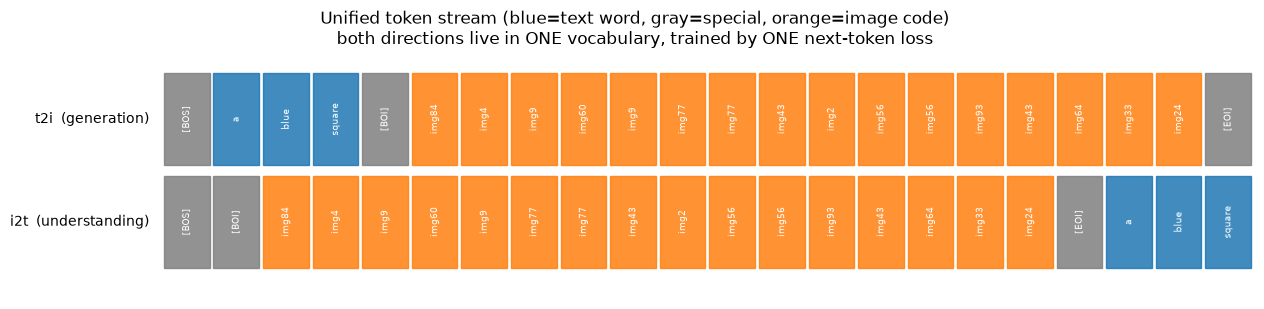

Vocabulary: 7 text words + 3 specials + 96 image codes = 106 tokens


In [6]:
# ---- 统一词表:文本词 + 特殊符 + 图像code ----
WORDS = ['a', 'red', 'green', 'blue', 'circle', 'square', 'triangle']
W2I = {w: i for i, w in enumerate(WORDS)}
BOS, BOI, EOI = 7, 8, 9      # 特殊符:序列开始 / 图像开始 / 图像结束
IMG_BASE = 10                # 图像code的token下标从10开始
V = IMG_BASE + K             # 词表大小 = 10 + 96 = 106
T = 22                       # 序列长度 = [BOS]+3文字+[BOI]+16图像+[EOI]
I2W = {v: k for k, v in W2I.items()}
I2W.update({BOS: '[BOS]', BOI: '[BOI]', EOI: '[EOI]'})

def cap_tokens(k):
    """Class index -> 3 caption tokens 'a {color} {shape}'"""
    c, s = ALL_PAIRS[k]
    return [W2I['a'], W2I[c], W2I[s]]

# 图像 -> 16个图像code(加IMG_BASE偏移,落到词表的图像区)
img_toks_tr = vq_encode(Xtr, codebook) + IMG_BASE
img_toks_te = vq_encode(Xte, codebook) + IMG_BASE

def seq_t2i(k, it):
    """text->image: [BOS] a color shape [BOI] <16 img tokens> [EOI]"""
    return np.array([BOS] + cap_tokens(k) + [BOI] + list(it) + [EOI])

def seq_i2t(k, it):
    """image->text: [BOS] [BOI] <16 img tokens> [EOI] a color shape"""
    return np.array([BOS, BOI] + list(it) + [EOI] + cap_tokens(k))

# 画一个示意图:同一批里两种方向的序列
def tok_str(t):
    return I2W.get(t, f'img{t - IMG_BASE}')

fig, ax = plt.subplots(figsize=(13, 3.2))
ex_k = ytr[0]
s_t2i = seq_t2i(ex_k, img_toks_tr[0])
s_i2t = seq_i2t(ex_k, img_toks_tr[0])
for row, (seq, name) in enumerate([(s_t2i, 't2i  (generation)'), (s_i2t, 'i2t  (understanding)')]):
    for j, t in enumerate(seq):
        # 文字词=蓝,特殊符=灰,图像code=橙
        color = '#ff7f0e' if t >= IMG_BASE else ('#7f7f7f' if t in (BOS, BOI, EOI) else '#1f77b4')
        ax.add_patch(plt.Rectangle((j, -row), 0.92, 0.9, color=color, alpha=0.85))
        ax.text(j + 0.46, -row + 0.45, tok_str(t), ha='center', va='center',
                fontsize=6.5, color='white', rotation=90)
    ax.text(-0.3, -row + 0.45, name, ha='right', va='center', fontsize=10)
ax.set_xlim(-3, T); ax.set_ylim(-1.3, 1.1); ax.axis('off')
ax.set_title('Unified token stream (blue=text word, gray=special, orange=image code)\n'
             'both directions live in ONE vocabulary, trained by ONE next-token loss')
plt.tight_layout(); plt.show()
print(f'Vocabulary: {len(WORDS)} text words + 3 specials + {K} image codes = {V} tokens')

## 统一自回归 Transformer(因果 mask,手写反向传播)

#### 💻 代码解读

**做什么:** 定义并初始化统一 Transformer 的全部参数:一张**共享嵌入表**(文字词和图像 code 共用)、可学习位置编码、2 层因果 Transformer 编码器(4 头注意力 + MLP)、输出到整个词表的分类头,共约 10.6 万参数。

**怎么做:**
- **一张嵌入表 `Emb` (V,D)**:文字 token 和图像 code 查同一张表——这是早融合的字面意义。对比 34(LLaVA)要用一层投影把视觉特征"翻译"进词嵌入空间,这里图像 code 天生就是词表的一员,不需要任何桥。
- 2 层编码器,每层:注意力四投影 `Wq/Wk/Wv/Wo` + MLP(D→224→D)+ 两处 RMSNorm 增益。
- **RMSNorm 代替 LayerNorm**(与本仓库 32 号 ViT 一致):只除以均方根、乘增益,不减均值、无 β,反传更简洁,效果实践中等价(LLaMA/T5 均用)。这是本实现相对原版的简化,注明差异。
- **QK-Norm 说明**:真实 Chameleon 为了让图像/文字 token 混训不发散,对注意力的 Q、K 额外做归一化(QK-Norm)。本玩具规模用不到,但这是早融合稳定训练的关键技巧,在此点明。
- 与 33/34 的对照:这里**没有冻结塔、没有桥接模块**,所有 10.6 万参数都参与训练、都共享。

In [7]:
D, H, L, HID = 64, 4, 2, 224  # 模型宽度/头数/层数/MLP隐层
DH = D // H                    # 每头维度16
EPS = 1e-6

def init_params(rng):
    """All parameters in one flat dict; image codes & text words share Emb"""
    # 共享嵌入表:文字词和图像code查同一张表(early fusion的字面含义)
    p = {'Emb': rng.normal(0, 0.02, (V, D)), 'pos': rng.normal(0, 0.02, (T, D))}
    for l in range(L):
        p[f'{l}g1'] = np.ones(D)            # 注意力前RMSNorm增益
        for nm in ['Wq', 'Wk', 'Wv', 'Wo']:
            p[f'{l}{nm}'] = rng.normal(0, np.sqrt(1 / D), (D, D))
        p[f'{l}g2'] = np.ones(D)            # MLP前RMSNorm增益
        p[f'{l}W1'] = rng.normal(0, np.sqrt(2 / D), (D, HID))
        p[f'{l}b1'] = np.zeros(HID)
        p[f'{l}W2'] = rng.normal(0, np.sqrt(2 / HID), (HID, D))
        p[f'{l}b2'] = np.zeros(D)
    p['gf'] = np.ones(D)                    # 分类头前最终RMSNorm
    p['Wh'] = rng.normal(0, np.sqrt(1 / D), (D, V))  # 输出到整个词表
    p['bh'] = np.zeros(V)
    return p

def rms_fwd(x, g):
    """RMSNorm: y = x / rms(x) * g (无减均值、无beta,cf. 原版的LayerNorm)"""
    r = np.sqrt((x ** 2).mean(-1, keepdims=True) + EPS)
    return x / r * g, (x, r)

def rms_bwd(dy, cache, g):
    x, r = cache
    dg = (dy * x / r).sum(tuple(range(x.ndim - 1)))
    u = dy * g
    # 扣除沿x自身方向的径向分量(x等比缩放不改变输出,该方向导数为0)
    dx = u / r - x * (u * x).sum(-1, keepdims=True) / (x.shape[-1] * r ** 3)
    return dx, dg

def split_heads(z):
    """(N,T,D) -> (N,H,T,DH)"""
    N, t, _ = z.shape
    return z.reshape(N, t, H, DH).transpose(0, 2, 1, 3)

def merge_heads(z):
    """(N,H,T,DH) -> (N,T,D)"""
    N, _, t, _ = z.shape
    return z.transpose(0, 2, 1, 3).reshape(N, t, D)

p0 = init_params(np.random.default_rng(3))
n_params = sum(v.size for v in p0.values())
print(f'Unified AR Transformer: {L} layers, {H} heads, d_model={D}, {n_params:,} parameters')
print(f'  ONE shared embedding table Emb{p0["Emb"].shape} for text words AND image codes')
print(f'  no frozen tower, no bridge -- every parameter is trained and shared')

Unified AR Transformer: 2 layers, 4 heads, d_model=64, 106,090 parameters
  ONE shared embedding table Emb(106, 64) for text words AND image codes
  no frozen tower, no bridge -- every parameter is trained and shared


#### 💻 代码解读

**做什么:** 实现前向传播——共享嵌入 + 位置编码 → 2 层(RMSNorm → **因果**多头自注意力 → 残差 → RMSNorm → MLP → 残差)→ 最终 RMSNorm → 词表分类头。因果 mask 是自回归的关键:每个位置只能看到自己和左边。

**怎么做:**
- **因果 mask**:`np.triu(..., 1)` 造一个上三角 -1e9 矩阵加到注意力分数上,让 softmax 后"看未来"的权重为 0——这样第 i 个 token 的预测只依赖前 i 个,才能做 next-token 训练与自回归生成。
- pre-norm 残差结构(`x + Attn(Norm(x))`),干净的梯度主通路(呼应本仓库 15 号 ResNet 恒等映射)。
- 多头注意力用 `@` 对 (N,H) 两个 batch 维自动广播,一次算出 (N,H,T,T) 注意力;softmax 前减每行最大值防上溢。
- 每步的中间量存入 cache,供反向传播。

In [8]:
def forward(p, toks):
    """Causal AR forward from token indices (N,T) -> logits (N,T,V) + cache"""
    N, t = toks.shape
    cache = {'toks': toks, 't': t}
    x = p['Emb'][toks] + p['pos'][:t]                 # 查共享嵌入表 + 位置编码
    # 因果mask:上三角(不含对角)设为-1e9,softmax后"看未来"权重为0
    mask = np.triu(np.full((t, t), -1e9), 1)
    for l in range(L):
        c = {'x_in': x}
        xn, c['n1'] = rms_fwd(x, p[f'{l}g1'])
        c['xn'] = xn
        q = split_heads(xn @ p[f'{l}Wq'])             # (N,H,T,DH)
        k = split_heads(xn @ p[f'{l}Wk'])
        v = split_heads(xn @ p[f'{l}Wv'])
        # 缩放点积注意力 + 因果mask:@对(N,H)两个batch维自动广播
        A = softmax(q @ k.transpose(0, 1, 3, 2) / np.sqrt(DH) + mask)
        mh = merge_heads(A @ v)
        x = x + mh @ p[f'{l}Wo']                      # 残差
        c.update(q=q, k=k, v=v, A=A, mh=mh)
        hn, c['n2'] = rms_fwd(x, p[f'{l}g2'])
        c['hn'] = hn
        h1 = hn @ p[f'{l}W1'] + p[f'{l}b1']
        hr = np.maximum(h1, 0)
        x = x + hr @ p[f'{l}W2'] + p[f'{l}b2']        # 残差
        c.update(h1=h1, hr=hr)
        cache[l] = c
    xn, cache['nf'] = rms_fwd(x, p['gf'])
    cache['xf'] = xn
    return xn @ p['Wh'] + p['bh'], cache

_lg, _ = forward(p0, np.stack([seq_t2i(ytr[0], img_toks_tr[0]),
                               seq_i2t(ytr[1], img_toks_tr[1])]))
print(f'logits shape: {_lg.shape}  (batch, seq_len={T}, vocab={V})')

logits shape: (2, 22, 106)  (batch, seq_len=22, vocab=106)


#### 💻 代码解读

**做什么:** 手写反向传播,把 next-token 交叉熵损失的梯度反传过分类头、最终归一化、两层编码器直到共享嵌入表。这里加了 Chameleon 混训的关键工程点:**按方向平衡损失权重**。

**怎么做(梯度怎么流):**
- **prompt-masking + 方向平衡**(`lmask`):我们只在每个方向的**回答**部分计损失——文生图方向回答是图像 token(17 个),图生文方向回答是文字 token(3 个)。更重要的是给每个 token 的权重 = 1/(该序列回答 token 数),让**每个样本贡献相等的总梯度**。否则占数量优势的 17 个图像 token 会淹没 3 个文字 token,导致训练后期理解能力(看图说话)悄悄退化——这是早融合混训的真实陷阱。
- **softmax + 交叉熵**合并梯度 = `probs − onehot`(乘以样本权重)。
- **残差**:`dx = dx + 支路梯度`,梯度沿主通路原样直达。
- **RMSNorm**:扣除径向分量(见 `rms_bwd`)。
- **因果 softmax 注意力**:`dS = A ⊙ (dA − Σ(dA⊙A))`,随后 `dQ=dS@K/√dh`、`dK=dSᵀ@Q/√dh`、`dV=Aᵀ@dAV`;因果 mask 位置的 A 本就是 0,梯度自动不流向未来。
- 嵌入表梯度用 `np.add.at` 按 token 下标散射累加(同一个 code 在序列里多次出现,梯度要累加)。

In [9]:
def loss_and_grads(p, toks, lmask=None):
    """Forward + full manual backward; lmask weights response tokens per position"""
    logits, cache = forward(p, toks)
    N, t = toks.shape
    lg = logits[:, :-1].reshape(-1, V)                # 预测位置0..T-2
    tgt = toks[:, 1:].reshape(-1)                     # 目标 = 右移一位
    probs = softmax(lg)
    n = len(tgt)
    # 损失权重:None=全部等权;否则按方向平衡(每个样本总权重相等)
    w = np.ones(n) if lmask is None else lmask.reshape(-1).astype(float)
    denom = w.sum() + 1e-12
    ce = -np.log(probs[np.arange(n), tgt] + 1e-12)
    loss = (ce * w).sum() / denom
    # 交叉熵对logits梯度 = probs - onehot,再乘样本权重
    dlg = probs.copy()
    dlg[np.arange(n), tgt] -= 1
    dlg *= (w / denom)[:, None]
    dlogits = np.zeros_like(logits)
    dlogits[:, :-1] = dlg.reshape(N, t - 1, V)

    g = {k: np.zeros_like(v) for k, v in p.items()}
    g['Wh'] = cache['xf'].reshape(-1, D).T @ dlogits.reshape(-1, V)
    g['bh'] = dlogits.sum((0, 1))
    dx, g['gf'] = rms_bwd(dlogits @ p['Wh'].T, cache['nf'], p['gf'])
    for l in reversed(range(L)):
        c = cache[l]
        # ---- MLP子层反向 ----
        g[f'{l}W2'] = c['hr'].reshape(-1, HID).T @ dx.reshape(-1, D)
        g[f'{l}b2'] = dx.sum((0, 1))
        dh1 = (dx @ p[f'{l}W2'].T) * (c['h1'] > 0)    # ReLU梯度
        g[f'{l}W1'] = c['hn'].reshape(-1, D).T @ dh1.reshape(-1, HID)
        g[f'{l}b1'] = dh1.sum((0, 1))
        dxm, g[f'{l}g2'] = rms_bwd(dh1 @ p[f'{l}W1'].T, c['n2'], p[f'{l}g2'])
        dx = dx + dxm                                 # 残差:主通路+支路
        # ---- 注意力子层反向 ----
        g[f'{l}Wo'] = c['mh'].reshape(-1, D).T @ dx.reshape(-1, D)
        dav = split_heads(dx @ p[f'{l}Wo'].T)
        dA = dav @ c['v'].transpose(0, 1, 3, 2)
        dv = c['A'].transpose(0, 1, 3, 2) @ dav
        # softmax反向(逐行):dS = A*(dA - sum(dA*A));因果位置A=0,梯度不流向未来
        dS = c['A'] * (dA - (dA * c['A']).sum(-1, keepdims=True))
        dq = dS @ c['k'] / np.sqrt(DH)
        dk = dS.transpose(0, 1, 3, 2) @ c['q'] / np.sqrt(DH)  # K在转置位置,用dS转置
        dq_m, dk_m, dv_m = merge_heads(dq), merge_heads(dk), merge_heads(dv)
        xn2 = c['xn'].reshape(-1, D)
        g[f'{l}Wq'] = xn2.T @ dq_m.reshape(-1, D)
        g[f'{l}Wk'] = xn2.T @ dk_m.reshape(-1, D)
        g[f'{l}Wv'] = xn2.T @ dv_m.reshape(-1, D)
        dxn = dq_m @ p[f'{l}Wq'].T + dk_m @ p[f'{l}Wk'].T + dv_m @ p[f'{l}Wv'].T
        dxi, g[f'{l}g1'] = rms_bwd(dxn, c['n1'], p[f'{l}g1'])
        dx = dx + dxi
    g['pos'][:cache['t']] = dx.sum(0)
    # 共享嵌入表:同一个token可能多次出现,梯度用add.at按下标散射累加
    np.add.at(g['Emb'], cache['toks'], dx)
    correct = (logits[:, :-1].argmax(-1) == toks[:, 1:]).reshape(-1)
    acc = (correct * w).sum() / denom                 # 加权的next-token准确率
    return loss, acc, g

# ---- 数值梯度校验:手写反传的必做仪式 ----
def grad_check():
    r2 = np.random.default_rng(1)
    p = init_params(r2)
    toks = np.array([seq_t2i(ytr[i], img_toks_tr[i]) for i in range(3)]
                    + [seq_i2t(ytr[i], img_toks_tr[i]) for i in range(3, 6)])
    _, _, g = loss_and_grads(p, toks)
    errs = {}
    for k in ['Emb', 'pos', '0Wq', '0g1', '1W2', 'gf', 'Wh']:
        w = p[k]
        idx = tuple(r2.integers(0, s) for s in w.shape)
        e = 1e-5
        w[idx] += e; l1, _, _ = loss_and_grads(p, toks)
        w[idx] -= 2 * e; l2, _, _ = loss_and_grads(p, toks)
        w[idx] += e
        num = (l1 - l2) / (2 * e)                      # 中心差分,误差O(e^2)
        errs[k] = abs(num - g[k][idx]) / (abs(num) + abs(g[k][idx]) + 1e-12)
    return errs

errs = grad_check()
for k, e in errs.items():
    print(f'  {k:>4s}: relative error = {e:.2e}')
print(f'max relative error = {max(errs.values()):.2e}  (< 1e-4 -> backprop is correct)')

   Emb: relative error = 2.90e-09
   pos: relative error = 3.36e-08
   0Wq: relative error = 2.87e-09
   0g1: relative error = 9.03e-10
   1W2: relative error = 9.85e-09
    gf: relative error = 1.53e-09
    Wh: relative error = 1.27e-08
max relative error = 3.36e-08  (< 1e-4 -> backprop is correct)


## 混合训练:同一个 batch 里两个方向一起喂

#### 💻 代码解读

**做什么:** 用混合的两个方向(45% 文生图 + 55% 图生文)训练统一模型 6000 步,记录损失、加权 next-token 准确率、以及理解方向的 caption 准确率演化。

**怎么做:**
- `make_batch`:每个样本随机决定方向(`dirs`),文生图用 `seq_t2i`、图生文用 `seq_i2t`;同时按方向给出损失权重 mask(`MASK_T2I`/`MASK_I2T`),回答 token 权重 = 1/回答长度,保证两个方向对每个样本贡献相等梯度。
- 一个 batch 里同时有两种方向的序列——这就是"混合模态早融合"的训练现场:模型不知道也不需要知道下一个 batch 是哪种,它只是在学"给定前缀,预测下一个 token",不管这个 token 是文字还是图像。
- 每 1000 步在测试集上评一次 caption 准确率(下一节定义 `eval_caption`),观察理解能力是否稳定爬升(方向平衡权重的作用就体现在这条曲线不再中途掉头)。

training the UNIFIED model on a mix of both directions (55% i2t, 45% t2i)...


  step 1000: loss=1.1522  weighted_tok_acc=0.677  caption_acc=0.843


  step 2000: loss=1.1522  weighted_tok_acc=0.676  caption_acc=0.860


  step 3000: loss=1.2477  weighted_tok_acc=0.647  caption_acc=0.863


  step 4000: loss=0.9869  weighted_tok_acc=0.729  caption_acc=0.873


  step 5000: loss=0.8005  weighted_tok_acc=0.769  caption_acc=0.857


  step 6000: loss=0.4517  weighted_tok_acc=0.876  caption_acc=0.860


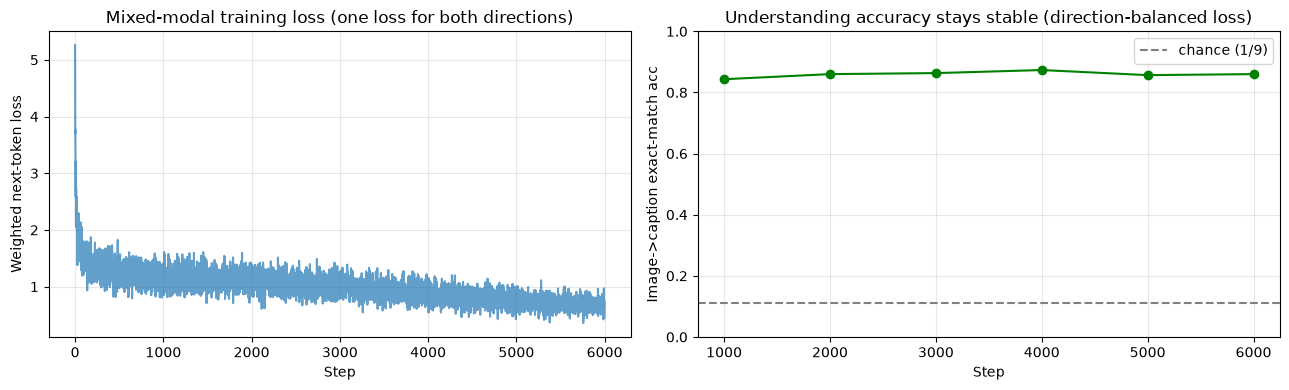

In [10]:
# 按方向的回答mask(作用在T-1个预测位置上):
# t2i [BOS a col shp BOI | i0..i15 EOI] -> 回答=图像token+EOI(17个)
# i2t [BOS BOI i0..i15 EOI | a col shp] -> 回答=caption(3个)
# 权重=1/回答长度 -> 每个样本贡献相等总梯度,避免17个图像token淹没3个文字token
MASK_T2I = np.zeros(T - 1); MASK_T2I[4:] = 1.0 / (T - 1 - 4)
MASK_I2T = np.zeros(T - 1); MASK_I2T[18:] = 1.0 / (T - 1 - 18)

def make_batch(idx, dirs):
    seqs = np.array([seq_t2i(ytr[i], img_toks_tr[i]) if d == 0
                     else seq_i2t(ytr[i], img_toks_tr[i]) for i, d in zip(idx, dirs)])
    masks = np.array([MASK_T2I if d == 0 else MASK_I2T for d in dirs])
    return seqs, masks

# ---- 生成/理解的推理与评估工具(训练中途也要用到) ----
TEXT_IDS = np.arange(7)                       # 文字词的token下标
IMG_IDS = np.arange(IMG_BASE, IMG_BASE + K)   # 图像code的token下标

def generate(p, prefix, n_new, allowed, temp=0.0, grng=None):
    """Autoregressively append n_new tokens, restricted to `allowed` vocab ids"""
    toks = prefix.copy()
    for _ in range(n_new):
        logits, _ = forward(p, toks)
        lg = logits[:, -1, :].copy()
        m = np.full(V, -1e9); m[allowed] = 0.0    # 屏蔽不允许的token(如生成图像时禁止输出文字)
        lg = lg + m
        if temp <= 0:
            nxt = lg.argmax(1)                    # 贪心解码
        else:
            pr = softmax(lg / temp)               # 温度采样
            cum = pr.cumsum(1)
            nxt = (cum < grng.random((len(toks), 1))).sum(1)
        toks = np.concatenate([toks, nxt[:, None]], 1)
    return toks

def eval_caption(p, imgs_toks, labels):
    """Understanding: image tokens -> generate 3 caption tokens, exact-match acc"""
    n = len(imgs_toks)
    prefix = np.concatenate([np.full((n, 1), BOS), np.full((n, 1), BOI),
                             imgs_toks, np.full((n, 1), EOI)], 1)
    caps = generate(p, prefix, 3, TEXT_IDS)[:, -3:]   # 只允许输出文字token
    tgt = np.array([cap_tokens(k) for k in labels])
    return (caps == tgt).all(1).mean(), caps

def train_model(seed, n_steps, mode='mixed', lr=2e-3, B=64, log=None):
    """mode: 'mixed'=both directions, 't2i'=text->image only (ablation)"""
    rt = np.random.default_rng(seed)
    p = init_params(rt)
    m = {k: np.zeros_like(v) for k, v in p.items()}
    v = {k: np.zeros_like(v_) for k, v_ in p.items()}
    hist, cap_hist, cap_steps = [], [], []
    for step in range(1, n_steps + 1):
        idx = rt.integers(0, len(Xtr), B)
        # mixed: 55%图生文 + 45%文生图(略偏理解方向,平衡"生成天生更难学"的不对称)
        dirs = (rt.random(B) < 0.55).astype(int) if mode == 'mixed' else np.zeros(B, int)
        seqs, masks = make_batch(idx, dirs)
        loss, acc, g = loss_and_grads(p, seqs, masks)
        # cosine学习率衰减到0.3倍:让这个小模型在训练末期稳定收敛在峰值附近,
        # 而不是被过高的恒定学习率来回震荡(理解方向的准确率对此尤其敏感)
        lr_t = lr * (0.3 + 0.7 * 0.5 * (1 + np.cos(np.pi * step / n_steps)))
        adam_update(p, g, m, v, step, lr=lr_t)
        hist.append(loss)
        if log and step % log == 0:
            ca, _ = eval_caption(p, img_toks_te, yte)
            cap_hist.append(ca); cap_steps.append(step)
            print(f'  step {step}: loss={loss:.4f}  weighted_tok_acc={acc:.3f}  caption_acc={ca:.3f}')
    return p, hist, cap_steps, cap_hist

print('training the UNIFIED model on a mix of both directions (55% i2t, 45% t2i)...')
params, hist, cap_steps, cap_hist = train_model(3, 6000, 'mixed', log=1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(hist, alpha=0.7)
ax1.set_xlabel('Step'); ax1.set_ylabel('Weighted next-token loss')
ax1.set_title('Mixed-modal training loss (one loss for both directions)')
ax1.grid(True, alpha=0.3)
ax2.plot(cap_steps, cap_hist, 'o-', color='green')
ax2.axhline(1/9, color='gray', ls='--', label='chance (1/9)')
ax2.set_xlabel('Step'); ax2.set_ylabel('Image->caption exact-match acc')
ax2.set_title('Understanding accuracy stays stable (direction-balanced loss)')
ax2.set_ylim(0, 1.0); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 双向评估:理解(看图说话)与生成(按文画图)都有硬数字

#### 💻 代码解读

**做什么:** 用同一个训练好的模型,量化两个方向:(a) **理解**——给测试图生成 caption 的精确匹配准确率;(b) **生成**——按 9 个 prompt 各生成一批图像 token,解码回像素,交给独立评委判类。

**怎么做:**
- `eval_caption`(上一节已定义):把图像 token 当前缀,自回归生成 3 个文字 token,和真值精确比对(颜色、形状全对才算对)。
- `eval_generation`:对每个类别,用前缀 `[BOS] a color shape [BOI]` 让模型自回归采样 16 个图像 code(温度采样增加多样性),`vq_decode` 回像素,评委判类,统计正确率。
- 生成用温度采样(temp=0.8)体现"同一 prompt 生成多样图像"。

In [11]:
def eval_generation(p, n_per=25, temp=0.8, seed=11):
    """Generation: for each class, sample images and score with the independent judge"""
    grng = np.random.default_rng(seed)
    accs, imgs_by_class = [], []
    for k in range(9):
        prefix = np.array([[BOS] + cap_tokens(k) + [BOI]] * n_per)
        gen_toks = generate(p, prefix, N_PATCH, IMG_IDS, temp=temp, grng=grng)[:, -N_PATCH:] - IMG_BASE
        gen_imgs = vq_decode(gen_toks, codebook)
        accs.append((judge(gen_imgs) == k).mean())
        imgs_by_class.append(gen_imgs)
    return np.array(accs), imgs_by_class

# (a) 理解方向
cap_acc, _ = eval_caption(params, img_toks_te, yte)
# (b) 生成方向
gen_accs, gen_imgs = eval_generation(params)
gen_acc = gen_accs.mean()

print(f'(a) UNDERSTANDING  image->caption exact-match acc: {cap_acc:.1%}   (chance 1/9={1/9:.1%})')
print(f'(b) GENERATION     caption->image judged acc:      {gen_acc:.1%}   (ceiling={judge_acc:.1%}, chance={1/9:.1%})')
print(f'    per-class generation acc: {dict(zip([f"{c[:1]}{s[:2]}" for c,s in ALL_PAIRS], np.round(gen_accs,2)))}')

(a) UNDERSTANDING  image->caption exact-match acc: 86.0%   (chance 1/9=11.1%)
(b) GENERATION     caption->image judged acc:      77.3%   (ceiling=89.0%, chance=11.1%)
    per-class generation acc: {'rci': np.float64(0.44), 'rsq': np.float64(0.84), 'rtr': np.float64(0.84), 'gci': np.float64(0.6), 'gsq': np.float64(0.72), 'gtr': np.float64(0.88), 'bci': np.float64(0.8), 'bsq': np.float64(0.96), 'btr': np.float64(0.88)}


#### 💻 代码解读

**做什么:** 展示两个方向的定性结果:上半张图是**按 prompt 分组的生成图像网格**(每个 prompt 生成多张),下半张图是**看图说话示例**(测试图 + 模型生成的 caption,对错标色)。

**怎么做:**
- 生成网格:9 个 prompt × 每行 6 张采样图,每行第一张图上方标注该行的 prompt;能看到同一 prompt 下图像有位置/大小多样性(温度采样的效果)。
- 看图说话:随机取若干测试图,画出模型生成的 caption,预测正确标绿、错误标红。

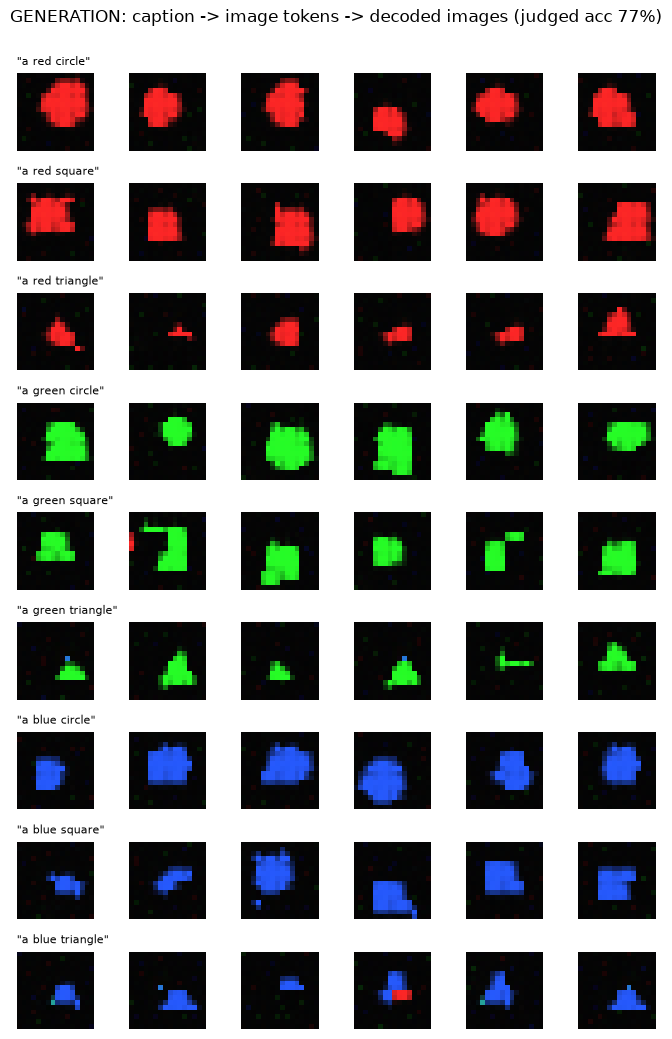

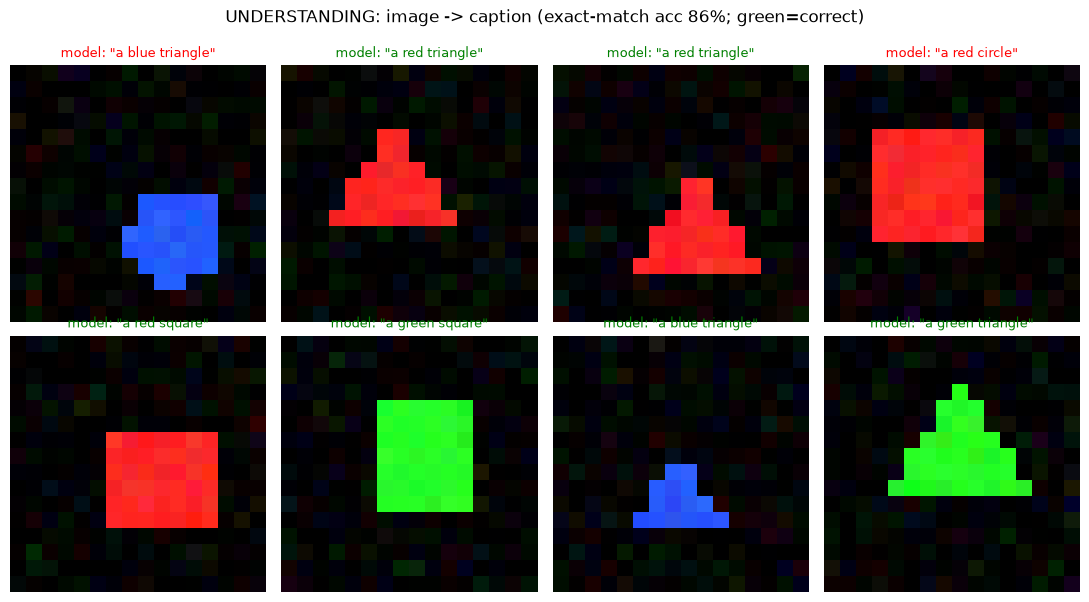

In [12]:
# --- 生成网格:按prompt分组 ---
n_show = 6
fig, axes = plt.subplots(9, n_show, figsize=(n_show * 1.15, 9 * 1.15))
for k in range(9):
    c, s = ALL_PAIRS[k]
    for j in range(n_show):
        ax = axes[k, j]
        ax.imshow(np.clip(gen_imgs[k][j], 0, 1))
        # axis('off')会隐藏ylabel,因此第一列用标题携带prompt
        if j == 0:
            ax.set_title(f'"a {c} {s}"', fontsize=8, loc='left')
        ax.axis('off')
plt.suptitle(f'GENERATION: caption -> image tokens -> decoded images (judged acc {gen_acc:.0%})', y=1.0)
plt.tight_layout(); plt.show()

# --- 看图说话示例 ---
gr = np.random.default_rng(4)
sh = gr.choice(len(Xte), 8, replace=False)
caps = eval_caption(params, img_toks_te[sh], yte[sh])[1]
fig, axes = plt.subplots(2, 4, figsize=(11, 6))
for ax, i, cap in zip(axes.flat, sh, caps):
    ax.imshow(Xte[i]); ax.axis('off')
    pred = ' '.join(I2W[t] for t in cap)
    true_k = yte[i]
    ok = list(cap) == cap_tokens(true_k)
    ax.set_title(f'model: "{pred}"', fontsize=9, color=('green' if ok else 'red'))
plt.suptitle(f'UNDERSTANDING: image -> caption (exact-match acc {cap_acc:.0%}; green=correct)', y=1.0)
plt.tight_layout(); plt.show()

## 招牌对比实验:统一混训 vs 单向训练(消融)

#### 💻 代码解读

**做什么:** 复现本篇最重要的对照——把**同一个模型只用文生图(t2i)数据**训练,看它另一个方向(看图说话)的能力如何。这直接回答"一份权重两种能力,是架构免费送的,还是混训买来的?"

**怎么做:**
- 用 `mode='t2i'` 重新初始化并训练一个结构完全相同的模型,只喂文生图序列(3000 步;混训 6000 步中约 45% 是 t2i,两者该方向的数据量大致对齐,但总算力约 2:1 偏向混训——这只会高估消融模型的生成方向,不影响结论)。
- 评它的两个方向:生成方向应该照样不错(它一直在练这个);理解方向(看图生成 caption)应该几乎为零——因为它从没见过"图像 token 在前、文字在后"的序列,这个方向的能力根本没被训练过。(实测 0.0% 甚至低于"9 选 1"的随机线 11.1%:贪心解码让未训练方向坍缩到同一个固定的错误 caption,而不是随机乱猜。)
- 画柱状图对比:混训模型(两个方向都行)vs 单向模型(只有一个方向)。**结论:统一模型的双向能力是双向混训一个 token 一个 token 喂出来的,不是白来的。**

training the ABLATION model: text->image direction ONLY...


  step 1500: loss=1.9105  weighted_tok_acc=0.461  caption_acc=0.003


  step 3000: loss=1.1880  weighted_tok_acc=0.680  caption_acc=0.000



t2i-ONLY model:  understanding(caption)=0.0%   generation=81.3%
MIXED     model:  understanding(caption)=86.0%   generation=77.3%


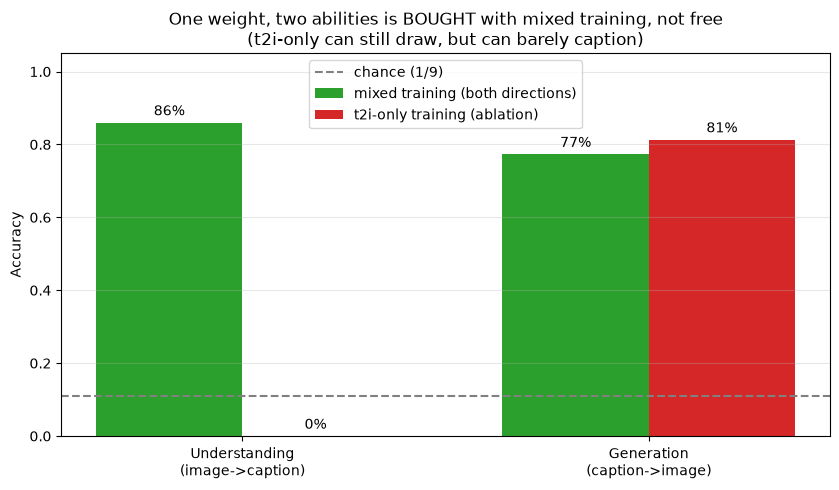

In [13]:
print('training the ABLATION model: text->image direction ONLY...')
params_t2i, _, _, _ = train_model(3, 3000, 't2i', log=1500)

cap_acc_ab, _ = eval_caption(params_t2i, img_toks_te, yte)
gen_acc_ab = eval_generation(params_t2i)[0].mean()
print(f'\nt2i-ONLY model:  understanding(caption)={cap_acc_ab:.1%}   generation={gen_acc_ab:.1%}')
print(f'MIXED     model:  understanding(caption)={cap_acc:.1%}   generation={gen_acc:.1%}')

labels = ['Understanding\n(image->caption)', 'Generation\n(caption->image)']
x = np.arange(2); wbar = 0.36
fig, ax = plt.subplots(figsize=(8.5, 5))
b1 = ax.bar(x - wbar/2, [cap_acc, gen_acc], wbar, label='mixed training (both directions)', color='#2ca02c')
b2 = ax.bar(x + wbar/2, [cap_acc_ab, gen_acc_ab], wbar, label='t2i-only training (ablation)', color='#d62728')
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02, f'{b.get_height():.0%}', ha='center', fontsize=10)
ax.axhline(1/9, color='gray', ls='--', label='chance (1/9)')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.05)
ax.set_title('One weight, two abilities is BOUGHT with mixed training, not free\n'
             '(t2i-only can still draw, but can barely caption)')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## 统一嵌入空间:文字词和图像 code 住在同一张表里

#### 💻 代码解读

**做什么:** 用 PCA 把共享嵌入表 `Emb`(106 个 token × 64 维)降到 2 维,按 token 类型着色,直观展示"早融合"的字面含义——文字词、特殊符、图像 code 是同一个空间里的公民,没有桥、没有翻译。

**怎么做:**
- 对 `Emb` 做中心化 + SVD(数值最稳的 PCA),取前两个主成分投影。
- 三类 token 用不同颜色/标记:文字词(蓝)、特殊符(灰)、图像 code(橙)。对比 34(LLaVA)需要一层投影把视觉特征搬进这个空间,这里图像 code 从初始化起就在表中,训练让它们各就各位。

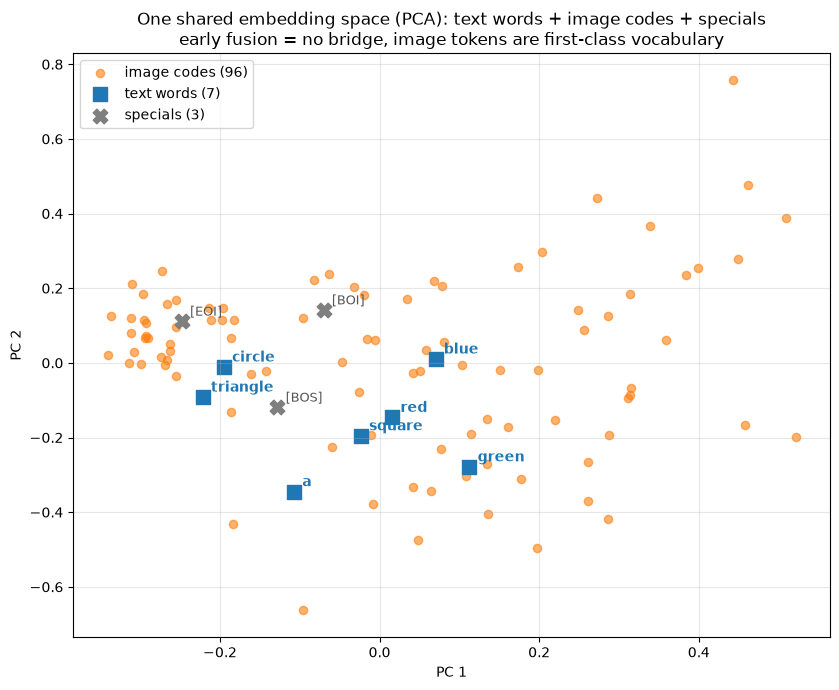

In [14]:
Emb = params['Emb']
Ec = Emb - Emb.mean(0)
U, S, Vt = np.linalg.svd(Ec, full_matrices=False)
proj = Ec @ Vt[:2].T  # (106,2)

plt.figure(figsize=(8.5, 7))
# 图像code
plt.scatter(proj[IMG_BASE:, 0], proj[IMG_BASE:, 1], c='#ff7f0e', s=35, alpha=0.6,
            label=f'image codes ({K})')
# 文字词
for i, w in enumerate(WORDS):
    plt.scatter(proj[i, 0], proj[i, 1], c='#1f77b4', s=90, marker='s')
    plt.annotate(w, proj[i], textcoords='offset points', xytext=(6, 4), fontsize=10,
                 color='#1f77b4', weight='bold')
# 特殊符
for t in (BOS, BOI, EOI):
    plt.scatter(proj[t, 0], proj[t, 1], c='#7f7f7f', s=110, marker='X')
    plt.annotate(I2W[t], proj[t], textcoords='offset points', xytext=(6, 4), fontsize=9, color='#555')
plt.scatter([], [], c='#1f77b4', marker='s', s=90, label='text words (7)')
plt.scatter([], [], c='#7f7f7f', marker='X', s=110, label='specials (3)')
plt.title('One shared embedding space (PCA): text words + image codes + specials\n'
          'early fusion = no bridge, image tokens are first-class vocabulary')
plt.xlabel('PC 1'); plt.ylabel('PC 2'); plt.legend(loc='best'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 参数量对照:没有冻结塔,没有桥,所有参数共享

#### 💻 代码解读

**做什么:** 打印统一模型的参数构成,并与 33(BLIP-2 冻结双塔 + Q-Former 桥)、34(LLaVA 冻结塔 + 投影)的范式做对照——本篇的招牌是**全部参数训练、全部共享**,参数表里没有"冻结"一栏。

**怎么做:** 按模块统计参数量,算各自占比;文字用中文说明与桥接范式的结构差异。

In [15]:
groups = {
    'shared embedding (text words + image codes)': params['Emb'].size,
    'position embedding': params['pos'].size,
    'transformer layers (attn + MLP + norms)': sum(v.size for k, v in params.items()
                                                   if k[0].isdigit()),
    'final norm + output head (to full vocab)': params['gf'].size + params['Wh'].size + params['bh'].size,
}
total = sum(groups.values())
print(f'{"module":<48s}{"params":>10s}{"share":>9s}')
print('-' * 67)
for k, v in groups.items():
    print(f'{k:<48s}{v:>10,d}{v/total:>8.1%}')
print('-' * 67)
print(f'{"TOTAL (all trained, all shared)":<48s}{total:>10,d}{1.0:>8.1%}')
print()
print('Contrast with the bridging paradigm:')
print('  31 CLIP      : dual towers, contrastive (LATE fusion; no generation)')
print('  33 BLIP-2    : FROZEN vision tower + FROZEN LLM + small Q-Former BRIDGE')
print('  34 LLaVA     : FROZEN vision tower + LLM + a projection layer BRIDGE')
print('  36 Chameleon : NO frozen tower, NO bridge -- 100% shared, born mixed (EARLY fusion)')

module                                              params    share
-------------------------------------------------------------------
shared embedding (text words + image codes)          6,784    6.4%
position embedding                                   1,408    1.3%
transformer layers (attn + MLP + norms)             90,944   85.7%
final norm + output head (to full vocab)             6,954    6.6%
-------------------------------------------------------------------
TOTAL (all trained, all shared)                    106,090  100.0%

Contrast with the bridging paradigm:
  31 CLIP      : dual towers, contrastive (LATE fusion; no generation)
  33 BLIP-2    : FROZEN vision tower + FROZEN LLM + small Q-Former BRIDGE
  34 LLaVA     : FROZEN vision tower + LLM + a projection layer BRIDGE
  36 Chameleon : NO frozen tower, NO bridge -- 100% shared, born mixed (EARLY fusion)


## Key Takeaways(要点总结)

1. **Discretize, then autoregress**: a toy VQ tokenizer turns each image into 16 discrete codes from a 96-word visual vocabulary; softmax needs a finite vocabulary, so discretization is the price of autoregressive image generation
2. **One vocabulary, one Transformer, one loss**: text words + image codes + specials share a single embedding table and a single causal Transformer trained with next-token cross-entropy — no vision encoder, no bridge, no frozen towers (106,090 params, all trained and shared)
3. **Both directions from one weight**: the mixed-trained model reaches 86.0% image→caption (understanding) and 77.3% caption→image judged accuracy (generation) at once
4. **Abilities are bought with mixed data**: a t2i-only model still generates (81.3%) but captions at 0.0% — bidirectional competence comes from bidirectional training, not from the architecture
5. **Discretization caps quality**: the VQ recon MSE curve (0.0190→0.0080 as K grows) and the judge's 89.0% ceiling on reconstructions bound generation quality — the same limit that pushed real Chameleon's successors (Transfusion) toward continuous diffusion heads

1. **先离散化,再自回归**:玩具 VQ 把每张图变成 96 词视觉词表里的 16 个离散 code;softmax 需要有限词表,所以离散化是自回归生成图像的代价
2. **一个词表、一个 Transformer、一个损失**:文字词 + 图像 code + 特殊符共享一张嵌入表和一个因果 Transformer,用 next-token 交叉熵训练——没有视觉编码器、没有桥、没有冻结塔(10.6 万参数全部训练、全部共享)
3. **一份权重两个方向**:混训模型同时做到 86.0% 看图说话(理解)与 77.3% 按文画图(生成)
4. **能力是混训买来的**:只训文生图的模型照样会生成(81.3%),看图说话却只有 0.0%——双向能力来自双向训练,不是架构自带
5. **离散化设了画质天花板**:VQ 重建 MSE 曲线(K 增大时 0.0190→0.0080)与评委在重建图上 89.0% 的上限共同框死了生成质量——正是这个限制把真实 Chameleon 的后继(Transfusion)推向了连续扩散头

**early fusion vs late fusion 的谱系(与本仓库多模态线的联系):**
- **31 CLIP**:双塔 + 对比学习,图文各编各的、只在末端对齐——**晚融合**,能理解检索,不能生成;
- **33 BLIP-2 / Flamingo**:冻结视觉塔 + 冻结语言模型 + 小小的 Q-Former **桥**——把连续视觉特征"翻译"进语言空间;
- **34 LLaVA**:冻结视觉塔 + 语言模型 + 一层线性**投影**桥——更简单的翻译;
- **36 Chameleon(本篇)**:**无桥、早融合**——图像离散化成 token,和文字混进同一个词表、同一个自回归模型,理解与生成是同一个模型的两个方向。

这条"统一 token 流"路线随后被 **Show-o**(离散扩散 + 自回归混合)、**Janus / Janus-Pro**(解耦理解与生成的视觉编码,但仍统一自回归)继承,并汇入 2026 年"原生多模态基础模型"的主流叙事。它的代价——VQ 离散化的画质天花板——直接催生了 **Transfusion**(在同一个 Transformer 里,文本走自回归离散 token、图像走连续扩散头),这也呼应了本仓库 **17 VAE**(连续潜变量生成)与离散 VQ 之间的张力:**生成到底该在离散 token 上做,还是在连续潜空间上做,是这条线至今仍在拉锯的核心问题。**